# Import Required Libs

In [77]:
# EDA
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import random

# KB
!pip install -q langchain_text_splitters
!pip install -q langchain langchain-community langchain-core langchain-huggingface
!pip install -q faiss-gpu
import langchain
import langchain_core
import langchain_huggingface
import langchain_community
print("langchain:", langchain.__version__)
print("langchain_core:", langchain_core.__version__)
print("langchain_community:", langchain_community.__version__)
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_community.vectorstores.utils import DistanceStrategy
import re

from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForMultipleChoice, Trainer

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

langchain: 1.2.15
langchain_core: 1.4.9
langchain_community: 0.4.2
/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv
/kaggle/input/datasets/kalyandath/science-dataset/physics_pages.csv
/kaggle/input/datasets/kalyandath/wiki-dataset/Wiki_knowledge_raw_gem.csv
/kaggle/input/datasets/kalyandath/wiki-dataset/Wiki_knowledge_raw.csv
/kaggle/input/datasets/kalyandath/deberta-pretrained/config.json
/kaggle/input/datasets/kalyandath/deberta-pretrained/training_args.bin
/kaggle/input/datasets/kalyandath/deberta-pretrained/tokenizer.json
/kaggle/input/datasets/kalyandath/deberta-pretrained/tokenizer_config.json
/kaggle/input/datasets/kalyandath/deberta-pretrained/model.safetensors


# Run Config

In [ ]:
EDA = False
RAG_KnowlegeBaseCreation = False

# Load the CSV files

In [4]:
train_df = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test_df  = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")

---

# Exploratory Data Analysis

## Look into the data

In [5]:
if EDA:
    train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   prompt  2000 non-null   object
 2   A       2000 non-null   object
 3   B       2000 non-null   object
 4   C       2000 non-null   object
 5   D       2000 non-null   object
 6   E       2000 non-null   object
 7   answer  2000 non-null   object
dtypes: int64(1), object(7)
memory usage: 125.1+ KB


In [6]:
if EDA:
    train_df.head()

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


## Look into the answer column

In [10]:
if EDA:
    print(f"Possible answer options in the trainig data: {sorted(train_df["answer"].unique())}")

Possible answer options in the trainig data: ['A', 'B', 'C', 'D', 'E']


In [18]:
if EDA:
    print("Distribution of answer options in the train data:")
    train_df["answer"].value_counts()

Distribution of answer options in the train data:


answer
B    490
C    459
A    369
D    358
E    324
Name: count, dtype: int64

<Axes: xlabel='answer'>

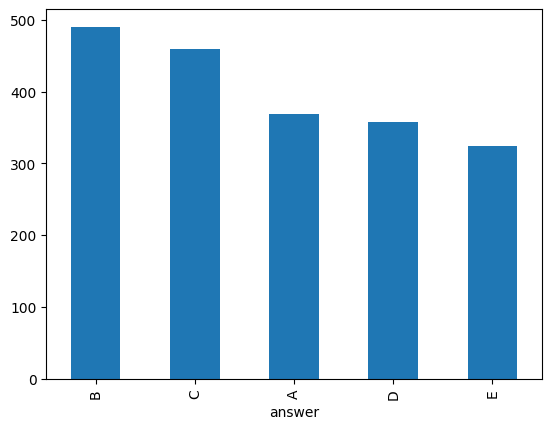

In [15]:
# Visualization of the Distribution
if EDA:
    train_df["answer"].value_counts().plot(kind="bar")

## Looking into the prompt column

In [25]:
if EDA:
    # Number of characters in the prompt column
    total_char = train_df["prompt"].apply(len).sum()
    total_prompts = len(train_df)
    
    print("Sum of characters in the prompt column:", total_char)
    print("Total num of prompts:", total_prompts)
    
    print("Average Character count:", total_char/total_prompts)
    print("Maximum Character count in a single prompt:", train_df["prompt"].apply(len).max())
    print("Minimum Character count in a single prompt:", train_df["prompt"].apply(len).min())
    print("Prompt with Minimum Characters:", train_df.iloc[train_df["prompt"].apply(len).idxmin()]["prompt"])
    print("Prompt with Maximum Characters:", train_df.iloc[train_df["prompt"].apply(len).idxmax()]["prompt"])

Sum of characters in the prompt column: 235339
Total num of prompts: 2000
Average Character count: 117.6695
Maximum Character count in a single prompt: 337
Minimum Character count in a single prompt: 19
Prompt with Minimum Characters: What is emissivity?
Prompt with Maximum Characters: Identify the correct statement: What is one of the examples of the models proposed by cosmologists and theoretical physicists without the cosmological or Copernican principles that can be used to address specific issues in the Lambda-CDM model and distinguish between current models and other possible models? based on the given context.


In [33]:
# Number of words in the prompt column
if EDA:
    def to_words(prompt):
        words = prompt.split()
        return len(words)
    
    total_words = train_df["prompt"].apply(to_words).sum()
    
    print("Total Number of words in the prompt column:", total_words)
    print("Total Number of prompts:", total_prompts)
    print("-"*50)
    
    print("Average word count in the prompt column:", total_words/total_prompts)
    print("Maximum word count in a single prompt:", train_df["prompt"].apply(to_words).max())
    print("Minimum word count in a single prompt:", train_df["prompt"].apply(to_words).min())

Total Number of words in the prompt column: 36293
Total Number of prompts: 2000
--------------------------------------------------
Average word count in the prompt column: 18.1465
Maximum word count in a single prompt: 51
Minimum word count in a single prompt: 3


## Look into a single row of train data

In [36]:
if EDA:
    index = random.randint(0,2000)
    print(f"Prompt:, {train_df.iloc[index]["prompt"]}\n")
    print(f"Option A: {train_df.iloc[index]["A"]}\n")
    print(f"Option B: {train_df.iloc[index]["B"]}\n")
    print(f"Option C: {train_df.iloc[index]["C"]}\n")
    print(f"Option D: {train_df.iloc[index]["D"]}\n")
    print(f"Option E: {train_df.iloc[index]["E"]}\n")
    print("Answer:", train_df.iloc[index]["answer"],":", train_df.iloc[index][train_df.iloc[index]["answer"]])

Prompt:, Choose the correct answer: What is the significance of the redshift-distance relationship in determining the expansion history of the universe? based on the given context.

Option A: Observations of the redshift-distance relationship can be used to determine the expansion history of the universe and the matter and energy content, especially for galaxies whose light has been travelling to us for much shorter times.

Option B: Observations of the redshift-distance relationship can be used to determine the age of the universe and the matter and energy content, especially for nearby galaxies whose light has been travelling to us for much shorter times.

Option C: Observations of the redshift-distance relationship can be used to determine the expansion history of the universe and the matter and energy content, especially for nearby galaxies whose light has been travelling to us for much longer times.

Option D: Observations of the redshift-distance relationship can be used to deter

## Insight

In [50]:
if EDA:
    duplicates = train_df["prompt"].duplicated().sum()
    print(f"Train data has {duplicates} duplicate questions!!! Need to drop these...")

Train data has 242 duplicate questions!!! Need to drop these...


In [52]:
train_df = train_df.drop_duplicates(subset="prompt")
print(f"After removing duplicates:")
print(f"Duplicates left:",train_df["prompt"].duplicated().sum())
print(f"Total prompts:", len(train_df))

After removing duplicates:
Duplicates left: 0
Total prompts: 1758


---

# RAG - Knowledge Base and FAISS Index Creation

## Config


In [57]:
DATA_PATH = "/kaggle/input/datasets/kalyandath/science-dataset/physics_pages.csv"
WIKI_DATH_PATH = "/kaggle/input/datasets/kalyandath/wiki-dataset/Wiki_knowledge_raw.csv"
data = pd.read_csv(DATA_PATH)
wiki_data = pd.read_csv(WIKI_DATH_PATH)

## Inspect the data

In [58]:
if RAG_KnowlegeBaseCreation:
    data.head()

,page,section_title,text
0,Electric field,Description,The electric field is defined at each point in...
1,Electric field,Mathematical formulation,Electric fields are caused by electric charges...
2,Electric field,Electrostatic fields,Electrostatic fields are electric fields that ...
3,Electric field,Electrodynamic fields,Electrodynamic fields are electric fields whic...
4,Electric field,Energy in the electric field,The total energy per unit volume stored by the...


In [59]:
if RAG_KnowlegeBaseCreation:
    wiki_data.head()

,title,content
0,API gravity,"The American Petroleum Institute gravity, or A..."
1,Absorption (electromagnetic radiation),"In physics, absorption of electromagnetic radi..."
2,Absorption spectroscopy,Absorption spectroscopy is spectroscopy that i...
3,Active transport,"In cellular biology, active transport is the m..."
4,Aerodynamics,Aerodynamics (from Ancient Greek ἀήρ (aḗr) 'a...


## Normalization to clean the data

In [62]:
if RAG_KnowlegeBaseCreation:
    print("Fields with empty content in physics data:", data["text"].isna().sum() + (data["text"] == "").sum())
    print("Fields with empty content in wiki data:", wiki_data["content"].isna().sum() + (wiki_data["content"] == "").sum())

Fields with empty content in physics data: 0
Fields with empty content in wiki data: 0


In [67]:
if RAG_KnowlegeBaseCreation:
    # Remove rows with content less than 50 chars
    print(f"Content with less than 50 chars:{(data["text"].str.len() < 50).sum()}")
    print(f"Content with less than 50 chars for wiki data:{(wiki_data["content"].str.len() < 50).sum()}")
    print("Remove contents having less than 50 characters.")
    data = data.loc[data["text"].str.len() > 50]
    wiki_data = wiki_data.loc[wiki_data["content"].str.len() > 50]

Content with less than 50 chars:0
Content with less than 50 chars for wiki data:0
Remove contents having less than 50 characters.


## Function clean the text content

In [68]:
if RAG_KnowlegeBaseCreation:
    def clean_text(text):
        # 1. Remove the wikipedia citation markers
        # [1], [23]
        text = re.sub(r'\[\d+\]\s*', "", text)
    
        # 2. Remove the section headers
        # === History ===, === References ===
        text = re.sub(r'^={2,}.*?={2,}', "", text, flags=re.MULTILINE)
    
        # 3. Remove "Source:" labels
        text = re.sub(r"Source:\s*(?=$|\n)","", text)
    
        # 4. Remove common latex commands
        # \frac, \alpha, \displaystyle
        text = re.sub(r'\\[a-zA-Z]+', " ", text)
    
        # 5. Remove leftover latex symbols
        text = re.sub(r"[{}\\^~]", " ", text)
    
        # 6. Remove page-number styes
        # : 327 , :  469-470
        text = re.sub(r":\s*\d+(?:-\d+)?\b", "", text)
    
        # 7 . Normalize whitespaces
        text = "\n".join(line.strip() for line in text.splitlines())
    
        # 8. Collapse multiple blank lines
        text = re.sub(r"\n{2,}", "\n", text)
    
        # 9. Convert everything into single para.
        text = text.replace("\n"," ").replace("\r", " ")
    
        # 10. Collapse sequence of whtiespace into a single space
        text = re.sub(r"\s+", " ",text)
    
        return text.strip()

## Process and clean content, create document for chunking

In [74]:
if RAG_KnowlegeBaseCreation:
# Define the text splitter
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size = 1000,
        chunk_overlap = 300,
        separators = [". ", "? ", "! ", ", ", " ", ""]
    )
    
    print("Creating the document data structure..")
    documents = []
    for index, row in data.iterrows():
        page = str(row["page"])
        title = str(row["section_title"])
        raw_text = str(row["text"])
        text = clean_text(raw_text)
        context_string = f"{page}:{title}\n\n{text}"
    
        documents.append(Document(
            page_content = context_string,
            metadata = {"source": f'{page}:{title}'}
        ))
    
    print("Successfully processed documents from physics dataset:", len(documents))
    
    for index, row in wiki_data.iterrows():
        title = str(row["title"])
        raw_text = str(row["content"])
        text = clean_text(raw_text)
        context_string = f"{title}\n\n{text}"
    
        documents.append(Document(
            page_content = context_string,
            metadata = {'source': title}
        ))
    print("Successfully processed documents from wiki dataset. Total Documents:", len(documents))

Creating the document data structure..
Successfully processed documents from physics dataset: 4070
Successfully processed documents from wiki dataset. Total Documents: 4710


## Chunkig Documents


In [76]:
if RAG_KnowlegeBaseCreation:
    filtered_documents = [doc for doc in documents if len(doc.page_content) > 100]
    chunks = text_splitter.split_documents(filtered_documents)
    print(f"Splitted documents into {len(chunks)} chunks...")

Splitted documents into 30597 chunks...


## Create FAISS Index with the chunks

In [ ]:
if RAG_KnowlegeBaseCreation:
    embeddings = HuggingFaceEmbeddings(
        model_name = "BAAI/bge-large-en-v1.5",
        model_kwargs = {'device':'cuda'}
    )
    
    vector_store = FAISS.from_documents(
        documents = chunks,
        embedding = embeddings,
        distance_strategy = DistanceStrategy.COSINE
    )

In [ ]:
# vector_store.save_local("/kaggle/working/faiss_index")

## Example query to the rag for testing

In [ ]:
if RAG_KnowlegeBaseCreation:
    query = "What is emissivity?"
    docs_scores = vector_store.similarity_search_with_score(query, k=3)
    top_doc = docs_scores[0][0]
    
    for doc,score in docs_scores:
        print(f"Score(Distance): {score:.4f}")
        print(f"Source: {doc.metadata['source']}\n")
        print(f"Content: {doc.page_content}\n---")


## Export FAISS Index to ZIP

In [ ]:
# import shutil
# shutil.make_archive("/kaggle/working/faiss_index_download", "zip", "/kaggle/working/faiss_index")

---

# Model: RAG Pipeline with LLM Inference

----

# Model: Bidirectional LSTM with Attention.

---

# Model: Pretrained Deberta Model with training.

In [17]:
MODEL = "/kaggle/input/datasets/kalyandath/deberta-pretrained/"

In [18]:
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForMultipleChoice.from_pretrained(MODEL)

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

In [19]:
## tokenization
def preprocess(data):
    output = {
        "input_ids": [],
        "attention_mask": [],
        "labels": []
    }

    label_map = {'A':0, 'B':1,'C':2, 'D':3, 'E':4}

    prompts = []
    options = []
    answer = []

    for i in range(len(data["prompt"])):
        prompts += [data["prompt"][i]] * 5
        options += [data[x][i] for x in label_map.keys()]
        answer.append(label_map[data["answer"][i]])

    tokenized_input = tokenizer(prompts, options, truncation = True, max_length = 256)
    
    for i in range(0, len(tokenized_input["input_ids"]),5):
        tokenized_return = {
            "input_ids": [],
            "attention_mask": [],
        }

        tokenized_return["input_ids"] += tokenized_input["input_ids"][i:i+5]
        tokenized_return["attention_mask"] += tokenized_input["attention_mask"][i:i+5]
        tokenized_return["labels"] = answer[i//5]

        output["input_ids"].append(tokenized_return["input_ids"])
        output["attention_mask"].append(tokenized_return["attention_mask"])
        output["labels"].append(tokenized_return["labels"])

    print(output["input_ids"][0])

    return output

In [20]:
## Load the test csv
test_df = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")
test_df["answer"] = "A"
test_dataset = Dataset.from_pandas(test_df)
tokenized_test = test_dataset.map(preprocess, batched=True)

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

[[1, 8498, 262, 410, 628, 1330, 294, 458, 269, 262, 1328, 457, 262, 92183, 268, 263, 53930, 36856, 267, 1850, 82785, 10272, 9143, 302, 3153, 260, 2, 434, 469, 53930, 6642, 265, 311, 92183, 261, 359, 1940, 92183, 303, 266, 5786, 53930, 6642, 275, 262, 454, 843, 260, 2], [1, 8498, 262, 410, 628, 1330, 294, 458, 269, 262, 1328, 457, 262, 92183, 268, 263, 53930, 36856, 267, 1850, 82785, 10272, 9143, 302, 3153, 260, 2, 434, 469, 53930, 6642, 265, 311, 92183, 261, 359, 1940, 92183, 303, 266, 5786, 53930, 6642, 275, 266, 1026, 843, 260, 2], [1, 8498, 262, 410, 628, 1330, 294, 458, 269, 262, 1328, 457, 262, 92183, 268, 263, 53930, 36856, 267, 1850, 82785, 10272, 9143, 302, 3153, 260, 2, 434, 469, 53930, 6642, 265, 311, 92183, 261, 359, 1940, 92183, 303, 266, 5786, 53930, 6642, 275, 266, 467, 5465, 260, 2], [1, 8498, 262, 410, 628, 1330, 294, 458, 269, 262, 1328, 457, 262, 92183, 268, 263, 53930, 36856, 267, 1850, 82785, 10272, 9143, 302, 3153, 260, 2, 434, 469, 53930, 6642, 265, 311, 92183, 26

In [23]:
from transformers import DataCollatorForMultipleChoice

data_collator = DataCollatorForMultipleChoice(tokenizer = tokenizer)
inference_trainer = Trainer(
    model = model,
    data_collator = data_collator
)

print("Running Predictions")
predictions = inference_trainer.predict(tokenized_test)
logits = predictions.predictions

Running Predictions


In [25]:
top_3_indices = np.argsort(logits, axis=1)[:,-1:-4:-1]
index_to_letter = {0:"A", 1:"B", 2:"C", 3:"D", 4: "E"}
predicted_strings = []

for row in top_3_indices:
    letters = [index_to_letter[idx] for idx in row]
    predicted_strings.append(" ".join(letters))

submission_df = pd.DataFrame({
    "id": test_df["id"],
    "prediction": predicted_strings
})

In [26]:
# Submission for pretrained model
submission_df.to_csv("submission.csv", index= False)
print(submission_df.head())

   id prediction
0   1      A D B
1   2      B D A
2   3      B E D
3   4      E C A
4   5      C D A
